In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchinfo import summary

In [2]:
X = torch.randn(500, 2)
y = (X[:, 0]**4 + 5*X[:, 1]**2 - 10 > 0).float().view(-1, 1)
X.shape, y.shape

(torch.Size([500, 2]), torch.Size([500, 1]))

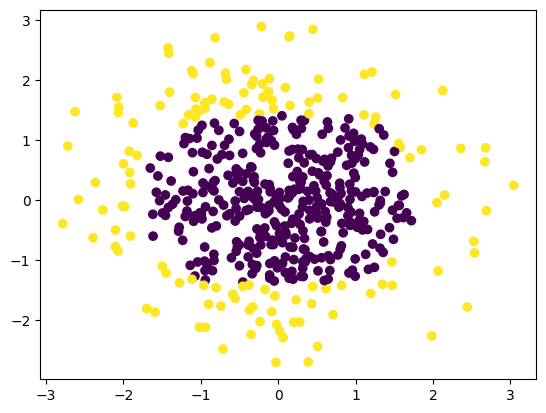

In [3]:
plt.scatter(X[:, 0], X[:, 1], c = y)

## 1. `nn.Sequential` API

Quickest way — just stack layers, no custom `forward` needed.

In [ ]:
# ── nn.Sequential API ──────────────────────────────────────────
# Quickest way to stack layers. No forward() needed.
# Great for simple, linear pipelines.

model_seq = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_seq.parameters(), lr=0.01)

epochs = 500
for epoch in range(epochs):
    output = model_seq(X)
    loss = criterion(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    preds = (model_seq(X) > 0.5).float()
    acc = (y == preds).float().mean()
    print(f'Sequential API — Accuracy: {acc:.4f}')

## 2. `nn.Module` Subclass API

Full control — define layers in `__init__`, wire them in `forward`.

In [4]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)

        out = self.fc2(out)
        out = self.relu(out)

        out = self.fc3(out)
        out = self.sigmoid(out)

        return out

In [5]:
model = FeedForwardNN(2, 16, 1)
summary(model)

Layer (type:depth-idx)                   Param #
FeedForwardNN                            --
├─Linear: 1-1                            48
├─Linear: 1-2                            272
├─Linear: 1-3                            17
├─ReLU: 1-4                              --
├─Sigmoid: 1-5                           --
Total params: 337
Trainable params: 337
Non-trainable params: 0

In [6]:
# 2 * 16 + 16 + 16 * 16 + 16 + 16 * 1 + 1

In [7]:
input_dim = 2
hidden_dim = 16
output_dim = 1
model = FeedForwardNN(input_dim, hidden_dim, output_dim)

criterian = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [8]:
epochs = 500
for epoch in range(epochs):
    output = model(X)
    loss = criterian(output, y)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step() 
    if (epoch + 1) % 100 == 0:
        print (f'Epoch : {epoch+ 1}/ {epochs}, Loss : {loss.item():.4f}')

Epoch : 100/ 500, Loss : 0.0297
Epoch : 200/ 500, Loss : 0.0092
Epoch : 300/ 500, Loss : 0.0040
Epoch : 400/ 500, Loss : 0.0022
Epoch : 500/ 500, Loss : 0.0014


In [9]:
with torch.no_grad():
    predictions = model(X)
    prediction_label = (predictions > 0.5).float()

    accuracy = (y == prediction_label).float().mean()
    print(f'Accuracy : {accuracy:.4f}')

Accuracy : 1.0000


In [10]:
## nn.ModuleList
class FeedForwardNN2(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim):
        super().__init__()

        self.hidden_layers = nn.ModuleList()
        self.hidden_layers.append(nn.Linear(input_dim, hidden_layers[0]))

        for i in range(1, len(hidden_layers)):
            self.hidden_layers.append(nn.Linear(hidden_layers[i-1], hidden_layers[i]))
        
        self.output_layer = nn.Linear(hidden_layers[-1], output_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        for layer in self.hidden_layers:
            input = layer(input)
            input = self.relu(input)

        input = self.output_layer(input)
        input = self.sigmoid(input)

        return input


In [11]:
input_dim  = 2
hidden_layers = [16, 32, 16] 
output_dim = 1
model = FeedForwardNN2(input_dim, hidden_layers, output_dim)
summary(model)

Layer (type:depth-idx)                   Param #
FeedForwardNN2                           --
├─ModuleList: 1-1                        --
│    └─Linear: 2-1                       48
│    └─Linear: 2-2                       544
│    └─Linear: 2-3                       528
├─Linear: 1-2                            17
├─ReLU: 1-3                              --
├─Sigmoid: 1-4                           --
Total params: 1,137
Trainable params: 1,137
Non-trainable params: 0

In [12]:
# 2 -> 16 -> 32 -> 16 -> 1
2 * 16 + 16 + 16 * 32 + 32 + 32 * 16 + 16 + 16 * 1 + 1

1137

In [13]:
criterian = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

epochs = 500
for epoch in range(epochs):
    outputs = model(X)
    loss = criterian(outputs, y)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print (f"Epoch {epoch + 1}/ {epochs}, Loss : {loss.item():.4f}")

Epoch 100/ 500, Loss : 0.0113
Epoch 200/ 500, Loss : 0.0036
Epoch 300/ 500, Loss : 0.0016
Epoch 400/ 500, Loss : 0.0009
Epoch 500/ 500, Loss : 0.0005


In [14]:
with torch.no_grad():

    predictions = model(X)
    prediction_label = (predictions > 0.5).float()

    accuracy = (y == prediction_label).float().mean()
    print(f'Accuracy {accuracy:.4f} ')

Accuracy 1.0000 


## 3. Configurable `nn.ModuleList` API

Pass an architecture spec — fully dynamic, no hardcoded layers.

In [15]:
# Configurable architecture
class ConfigurableNN(nn.Module):
    def __init__(self, architecture):
        super().__init__()

        self.layers = nn.ModuleList()

        for layer in architecture:
            layer_type = layer[0]
            if layer_type == "linear":
                in_dim, out_dim = layer[1], layer[2]
                self.layers.append(nn.Linear(in_dim, out_dim))

            elif layer_type == 'relu':
                self.layers.append(nn.ReLU())
            
            elif layer_type == 'tanh':
                self.layers.append(nn.Tanh())

            elif layer_type == 'sigmoid':
                self.layers.append(nn.Sigmoid())
            elif layer_type == 'dropout':
                p = layer[1]
                self.layers.append(nn.Dropout(p))
            else : 
                raise (ValueError(f'Unsupported layer : {layer_type}'))
            
    def forward(self, x):
        for layer in self.layers :
            x = layer(x)
        return x

In [16]:
architecture = [('linear', 2, 8),
                ('relu', ), 
                ('linear', 8, 16), 
                ('relu', ), 
                ('linear', 16 , 16), 
                ('relu', ), 
                ('linear', 16, 1), 
                ('sigmoid', )]
model = ConfigurableNN(architecture)

In [17]:
summary(model)

Layer (type:depth-idx)                   Param #
ConfigurableNN                           --
├─ModuleList: 1-1                        --
│    └─Linear: 2-1                       24
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       144
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       272
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       17
│    └─Sigmoid: 2-8                      --
Total params: 457
Trainable params: 457
Non-trainable params: 0

In [18]:
criterian = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
epochs = 500
for epoch in range(epochs):

    outputs = model(X)
    loss = criterian(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epochs {epoch + 1}/ (epochs), loss : {loss.item():.4f}')

Epochs 100/ (epochs), loss : 0.0264
Epochs 200/ (epochs), loss : 0.0079
Epochs 300/ (epochs), loss : 0.0041
Epochs 400/ (epochs), loss : 0.0024
Epochs 500/ (epochs), loss : 0.0016


In [19]:
summary(model)

Layer (type:depth-idx)                   Param #
ConfigurableNN                           --
├─ModuleList: 1-1                        --
│    └─Linear: 2-1                       24
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       144
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       272
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       17
│    └─Sigmoid: 2-8                      --
Total params: 457
Trainable params: 457
Non-trainable params: 0

In [20]:
# 2 -> 8 -> 16 -> 16 -> 1
2 * 8 + 8 + 8 * 16 + 16 + 16 * 16 + 16 + 16 * 1 + 1

457

## 4. `torch.nn.functional` API

Instead of defining activation/dropout layers as attributes in `__init__`, you call them as **stateless functions** directly inside `forward()` via `import torch.nn.functional as F`. Weights still live in `nn.Linear` — only the non-parametric ops move to `F`.

In [ ]:
import torch.nn.functional as F

class FeedForwardNN_Functional(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Only parametric layers go in __init__
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, training=False):
        # Non-parametric ops called as functions — no layer objects needed
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.2, training=training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.2, training=training)
        x = F.sigmoid(self.fc3(x))
        return x


In [ ]:
model_fn = FeedForwardNN_Functional(2, 16, 1)
summary(model_fn)


In [ ]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_fn.parameters(), lr=0.01)

epochs = 500
for epoch in range(epochs):
    output = model_fn(X, training=True)   # pass training=True so dropout is active
    loss = criterion(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')


In [ ]:
with torch.no_grad():
    predictions = model_fn(X, training=False)  # dropout off at inference
    prediction_label = (predictions > 0.5).float()
    accuracy = (y == prediction_label).float().mean()
    print(f'Functional API — Accuracy: {accuracy:.4f}')


In [21]:
# Visualizing Decision Boundary 
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_decision_boundary(mode, X, y):
    model.eval()

    if torch.is_tensor(X):
        X = X.detach().numpy()
    if torch.is_tensor(y):
        y = y.detach().numpy()

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    grid_tensor = torch.tensor(grid, dtype = torch.float32)
    with torch.no_grad():
        preds = model(grid_tensor)
        preds = (preds > 0.5).float().numpy()

    Z = preds.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha = 0.3, cmap = 'coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'coolwarm', edgecolors= 'k')
    plt.title ('Decision Boundary')
    plt.xlabel = 'Feature 1'
    plt.ylabel = 'Feature 2'
    plt.show()

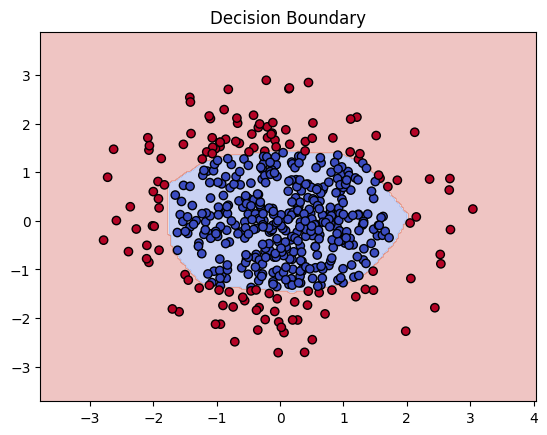

In [22]:
plot_decision_boundary(model, X, y)